# Set up

In [1]:
import pandas as pd
import missingno as ms
from collections import defaultdict
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
import joblib


seed = 85
sns.set_theme(style = 'ticks', palette = 'pastel')
pd.set_option('display.max_columns', None)

In [2]:
data = pd.read_csv('data/propertyfinder.csv')

C:\Users\Portable1\AppData\Local\Temp\ipykernel_2284\4151014025.py:1: DtypeWarning: Columns (0: completion_status) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('data/propertyfinder.csv')


# Preliminary cleaning

In [154]:
data.shape

(39713, 53)

In [155]:
data.head()

,listing_id,internal_id,category,listing_type,detail_url,property_type,offering_type,completion_status,title,price_egp,price_period,price_currency,location_full,city,town,district,subdistrict,lat,lon,bedrooms,bathrooms,area_value,area_unit,furnished,listing_level,is_premium,is_verified,is_featured,is_new_construction,is_direct_from_dev,is_exclusive,listed_date,images_count,has_view_360,video_url,reference,rera,description,amenities,payment_method,agent_id,agent_name,agent_email,agent_is_super,agent_languages,broker_id,broker_name,broker_email,broker_phone,contact_phone,contact_whatsapp,contact_email,scraped_at
0,F7QB31CGWE509V2W7DF2GARB2C,56009081.0,buy,property,https://www.propertyfinder.eg/en/plp/buy/duple...,Duplex,Residential for Sale,completed,Garden Villa - Lake View Boutique - Prime Loca...,24500000.0,sell,EGP,"The Lakeview Boutique Villas, 5th Settlement C...",Cairo,New Cairo City,The 5th Settlement,5th Settlement Compounds,30.040602,31.525942,3,6,445.0,sqm,NaN,premium,True,False,False,False,False,False,2026-03-03T19:15:06Z,6,False,NaN,F7QB31CGWE509V2W7DF2GARB2C,NaN,Garden Villa for Sale – Featured in Lake View ...,Balcony | Built in Wardrobes | Covered Parking...,cash,58866.0,pierre osama,pierre.Osama@spade-consultancy.com,False,NaN,5758.0,Spade consultancy,mohmedg.sedik@gmail.com,1.001437e+09,2.012018e+11,2.022126e+10,pierre.Osama@spade-consultancy.com,2026-03-04T14:20:33.281007
1,K1JC3D6N57ED52N3VX1QQKHHXG,56247925.0,buy,property,https://www.propertyfinder.eg/en/plp/buy/apart...,Apartment,Residential for Sale,off_plan,For Sale: Finished Apartment+ ACs in Village West,5145000.0,sell,EGP,"Village West, Sheikh Zayed Compounds, Sheikh Z...",Giza,Sheikh Zayed City,Sheikh Zayed Compounds,Village West,30.048094,31.020054,2,2,123.0,sqm,PARTLY,premium,True,False,False,False,False,False,2026-03-04T11:24:23Z,10,False,NaN,rb304,NaN,For Sale: Finished Apartment with ACs in Villa...,Balcony | Built in Wardrobes | Central A/C | C...,cash,67166.0,Rana Bahaa ElDeen,ranoushamer901@gmail.com,False,NaN,492.0,Abrag Real Estate,snawara71@gmail.com,2.010012e+11,2.010072e+11,2.022126e+10,ranoushamer901@gmail.com,2026-03-04T14:20:33.281007
2,Q6GEB8T6PZTJGNNPWA5PX3JCWR,56253883.0,buy,property,https://www.propertyfinder.eg/en/plp/buy/apart...,Apartment,Residential for Sale,completed,UnderMarket Price for Apt. 250 RTM PrimeLocation,10800000.0,sell,EGP,"Palm Hills New Cairo, 5th Settlement Compounds...",Cairo,New Cairo City,The 5th Settlement,5th Settlement Compounds,30.012272,31.579515,4,4,250.0,sqm,NaN,premium,True,False,False,False,False,False,2026-03-04T14:03:51Z,13,False,NaN,250pncash,NaN,Palm Hills New Cairo Apartment BUA: 250sqm 4 B...,Balcony | Built in Wardrobes | Central A/C | C...,cash,47158.0,Ashraf Shaaban,ashrafsobhy99@hotmail.com,False,English | Arabic,5279.0,Premises,mahmouddessam@hotmail.com,2.010051e+11,2.010910e+11,2.022126e+10,ashrafsobhy99@hotmail.com,2026-03-04T14:20:33.281007
3,PPH0852SAB266X6GSVATJP4F0M,56250852.0,buy,property,https://www.propertyfinder.eg/en/plp/buy/apart...,Apartment,Residential for Sale,completed,lowest price 2bds fullyfurnished @ lake view,10500000.0,sell,EGP,"Lake View Residence, 5th Settlement Compounds,...",Cairo,New Cairo City,The 5th Settlement,5th Settlement Compounds,30.026146,31.536974,2,2,136.0,sqm,YES,premium,True,False,False,False,False,False,2026-03-04T12:38:11Z,11,False,NaN,PPH0852SAB266X6GSVATJP4F0M,NaN,Lake View Residence 136 sqm Fully Finished Ren...,Balcony | Built in Wardrobes | Central A/C | C...,cash,63401.0,ebrahim hossam,ebrahim.hossam@spade-consultancy.com,False,NaN,5758.0,Spade consultancy,mohmedg.sedik@gmail.com,1.001437e+09,2.010701e+11,2.022126e+10,ebrahim.hossam@spade-consultancy.com,2026-03-04T14:20:33.281007
4,QCSA4TNDEBBV7BNY8ANST3TB50,55995764.0,buy,property,https://www.propertyfinder.eg/en/plp/buy/villa...,Villa,Residential for Sale,completed,Exclusive Type M with Lowest Price RTM in PNC,19500000.0,sell,EGP,"Palm Hills New Cairo, 5th Settlement Compounds...",Cairo,New

Let's only select properties to buy.

In [156]:
data = data.loc[data['category'] == 'buy', :]

Since we want to predict the price, let's get rid of rows for which the price is missing.

In [157]:
data = data.dropna(subset = ['price_egp'])

Let's see if there are duplicates and, if so, get rid of them.

In [158]:
print('Number of duplicates :', data.duplicated(keep = 'first').sum())

Number of duplicates : 0


In [159]:
data.rename(columns = {'price_egp' : 'price (EGP)'}, inplace = True)

Since we want to link to model to a CRP server, the prediction will be based on what the customer provides as criteria for a property to buy. Let's then get rid of all the columns giving details on information the customer won't have or provide.

In [160]:
data.drop(
    columns = [
        'listing_id', 'internal_id', 'detail_url', 'completion_status', 'title', 'price_period', 'price_currency', 'location_full',\
        'town', 'district', 'subdistrict', 'lat', 'lon', 'area_unit', 'furnished', 'listing_level', 'is_premium', 'is_verified',\
        'is_featured', 'is_new_construction', 'is_direct_from_dev', 'is_exclusive', 'listed_date', 'images_count', 'has_view_360',\
        'video_url', 'reference', 'rera', 'amenities', 'description', 'payment_method', 'agent_id', 'agent_name', 'agent_email', 'agent_is_super',\
        'agent_languages', 'broker_id', 'broker_name', 'broker_email', 'broker_phone', 'contact_phone', 'contact_whatsapp',\
        'contact_email','scraped_at'
    ],
    inplace = True
)

In [161]:
data.head()

,category,listing_type,property_type,offering_type,price (EGP),city,bedrooms,bathrooms,area_value
0,buy,property,Duplex,Residential for Sale,24500000.0,Cairo,3,6,445.0
1,buy,property,Apartment,Residential for Sale,5145000.0,Giza,2,2,123.0
2,buy,property,Apartment,Residential for Sale,10800000.0,Cairo,4,4,250.0
3,buy,property,Apartment,Residential for Sale,10500000.0,Cairo,2,2,136.0
4,buy,property,Villa,Residential for Sale,19500000.0,Cairo,4,4,255.0


Moreover, let's only keep properties for which a private individual might be actually interested in (so let's get rid of ```Whole Building```, ```Roof```, ```Half Floor```, ```Full Floor```, ```Bulk Sale Unit``` and ```Land```).

In [162]:
property_type_to_delete = data[data['property_type'].isin(['Whole Building', 'Roof', 'Half Floor', 'Full Floor', 'Bulk Sale Unit', 'Land'])].index

data.drop(index = property_type_to_delete, inplace = True)

In [163]:
data['property_type'].unique()

array(['Duplex', 'Apartment', 'Villa', 'Penthouse', 'Twin House',
       'Townhouse', 'Chalet', 'iVilla', 'Hotel Apartment', 'Cabin',
       'Palace'], dtype=object)

Now, let's check if we have columns that are uninformative (constant column for instance).

In [164]:
unique_values = defaultdict(int)

for c in data.columns:
    amount_of_unique_values = len(data[c].unique())

    if amount_of_unique_values == 1:
        unique_values[c] = amount_of_unique_values

unique_values_series = pd.Series(unique_values)
unique_values_series

,0
category,1
listing_type,1
offering_type,1


Then, let's get rid of those columns.

In [165]:
data.drop(columns = ['category', 'listing_type', 'offering_type'], inplace = True)

Let's check for columns with too many missing values.

<Axes: >

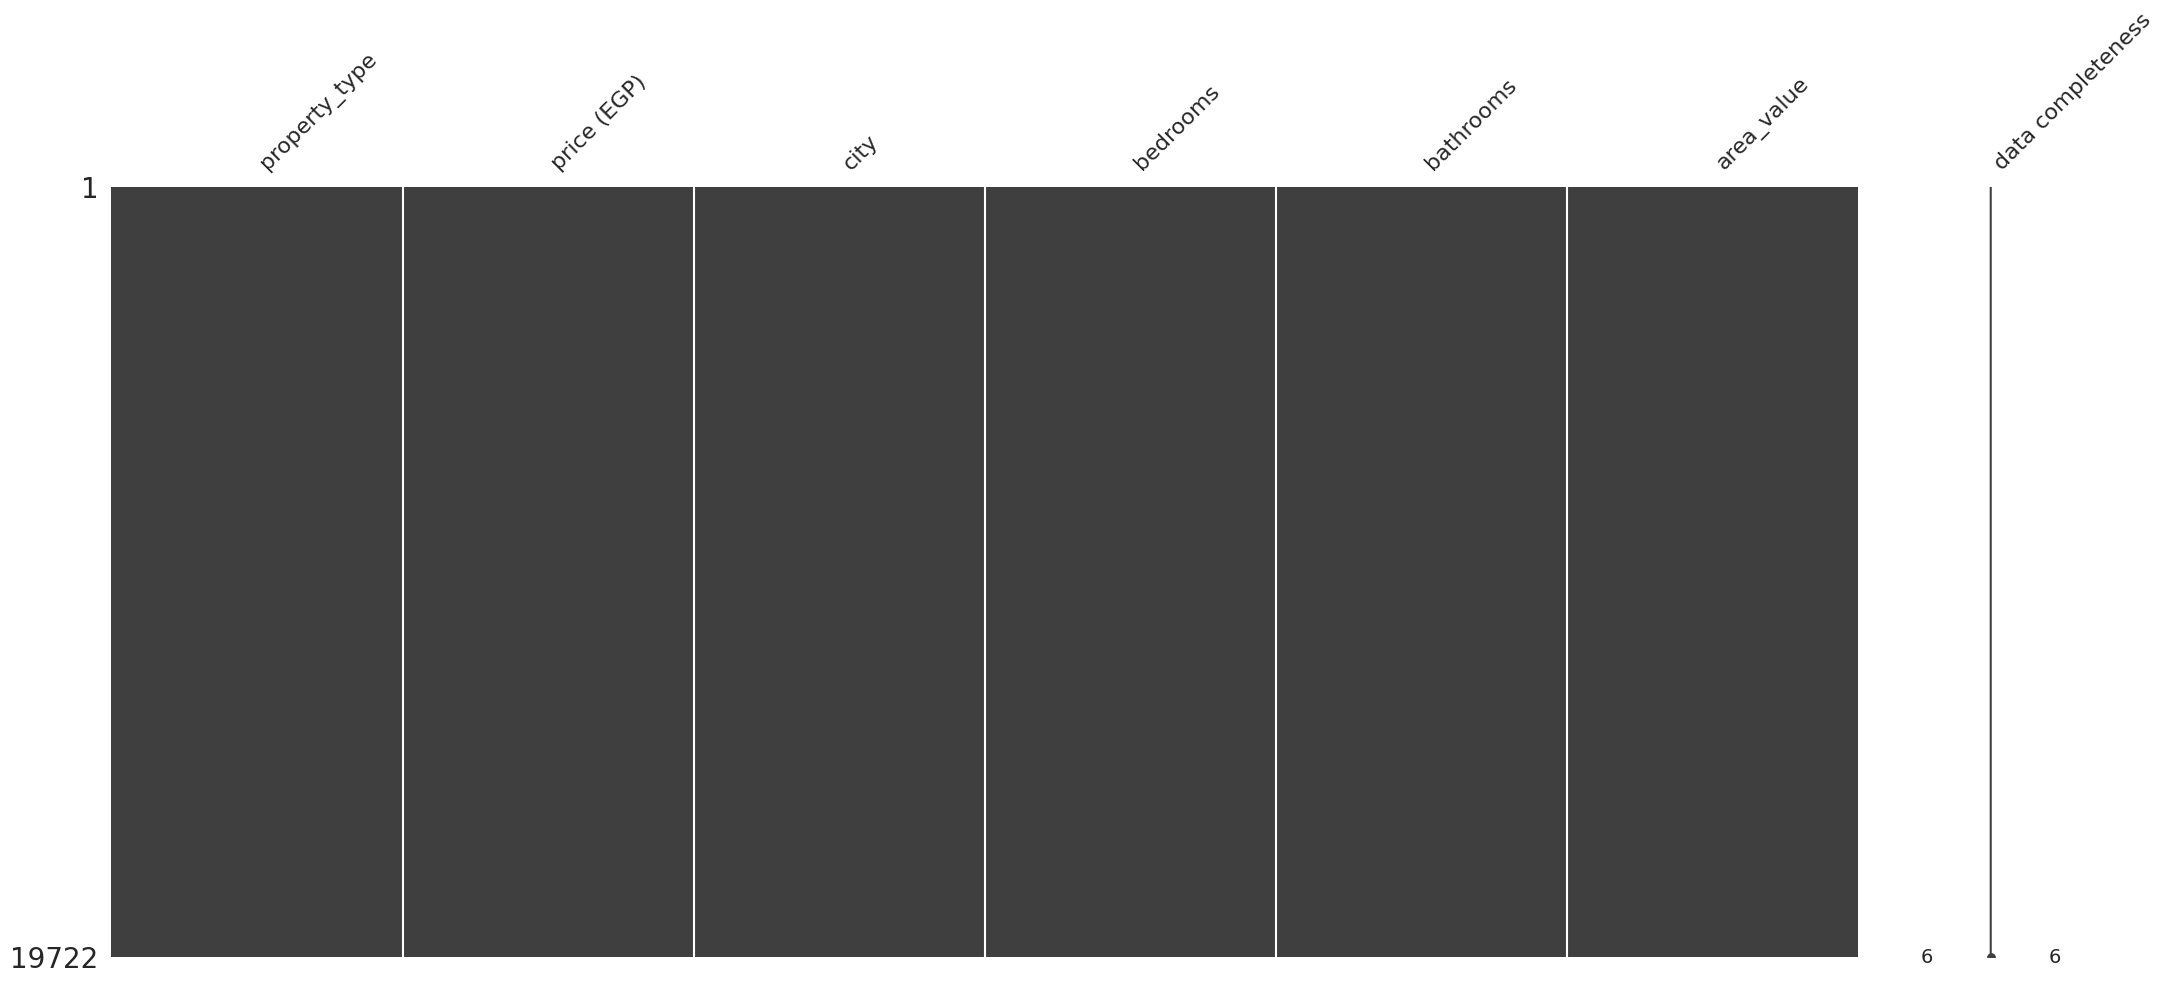

In [166]:
ms.matrix(data, sort = None, labels = True)

In [167]:
print('Missing values per column:')
missing_values_per_column = data.isna().sum(axis = 0).sort_values(ascending = False)
print(missing_values_per_column)
print('\n')

print(f'Remaining rows: {len(data)}')


Missing values per column:
property_type    0
price (EGP)      0
city             0
bedrooms         0
bathrooms        0
area_value       0
dtype: int64


Remaining rows: 19722


# EDA

## Splitting the data

Before performing the EDA, let's split the dataset to only take decisions and gain insights on the train set (to avoid data leakage) and build the pipeline accordingly.

In [168]:
X = data.drop(columns = ['price (EGP)'])
y = data['price (EGP)']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.15,
    random_state = seed
)

print(f'Train shape: {X_train.shape}, Test shape: {X_test.shape}')

Train shape: (16763, 5), Test shape: (2959, 5)


## Technical Cleaning

Let's start to clean the data we have (datatypes, obvious errors, capitals VS low case for strings...).

First, let's have a look at our remaining columns and their datatypes.

In [169]:
columns_to_inspect = ['property_type', 'city', 'bedrooms', 'bathrooms']

# Inspect simple categorical columns
for col in columns_to_inspect:
    print(f'Unique values for "{col}"')
    print(X_train[col].unique())
    print('\n')

Unique values for "property_type"
['Apartment' 'Villa' 'Chalet' 'Townhouse' 'Penthouse' 'Duplex'
 'Twin House' 'Hotel Apartment' 'iVilla' 'Cabin' 'Palace']


Unique values for "city"
['Red Sea' 'Cairo' 'Giza' 'North Coast' 'Suez' 'Qalyubia' 'Alexandria'
 'South Sainai' 'Sharqia' 'Matrouh' 'Demyat' 'Al Daqahlya']


Unique values for "bedrooms"
['1' '5' '3' '2' '4' 'studio' '7+' '7' '6']


Unique values for "bathrooms"
['1' '5' '3' '2' '4' '7+' '6' '7' 'none']




In [170]:
y_train.dtypes

dtype('float64')

In [171]:
X_train.dtypes

,0
property_type,object
city,object
bedrooms,object
bathrooms,object
area_value,float64


No problem for ```y_train```. However, the datatypes of ```bedrooms``` and ```bathrooms``` are not correct (since they are counting berooms and bathrooms in the properties so the datatypes should be ```int```).

And let's correct the datatypes of ```bedrooms``` and ```bathrooms```.

In [172]:
print(f'Unique values of "bedrooms": {X_train['bedrooms'].unique()}')
print(f'Unique values of "bathrooms": {X_train['bathrooms'].unique()}')

Unique values of "bedrooms": ['1' '5' '3' '2' '4' 'studio' '7+' '7' '6']
Unique values of "bathrooms": ['1' '5' '3' '2' '4' '7+' '6' '7' 'none']


We'll probably use ```bedrooms``` and ```bathrooms``` as categorical columns so let's replace ```7+``` by ```8``` and ```studio``` by ```0``` in ```bedrooms```, and ```7+``` by ```8``` and ```none``` by ```0``` in ```bathrooms```.

In [173]:
X_train['bedrooms'] = X_train['bedrooms'].replace(['7+', 'studio'], ['8', '0'])
X_train['bathrooms'] = X_train['bathrooms'].replace(['7+', 'none'], ['8', '0'])

Let's have a look at our data after this cleaning.

In [174]:
X_train.head()

,property_type,city,bedrooms,bathrooms,area_value
10362,Apartment,Red Sea,1,1,73.0
19604,Villa,Cairo,5,5,305.0
4645,Villa,Giza,5,5,220.0
4445,Apartment,Cairo,3,3,220.0
8576,Apartment,Cairo,2,2,138.0


In [175]:
X_train.shape

(16763, 5)

In [176]:
y_train.head()

,price (EGP)
10362,7200000.0
19604,19625000.0
4645,7000000.0
4445,8750000.0
8576,4600000.0


## Univariate & Multivariate Analysis

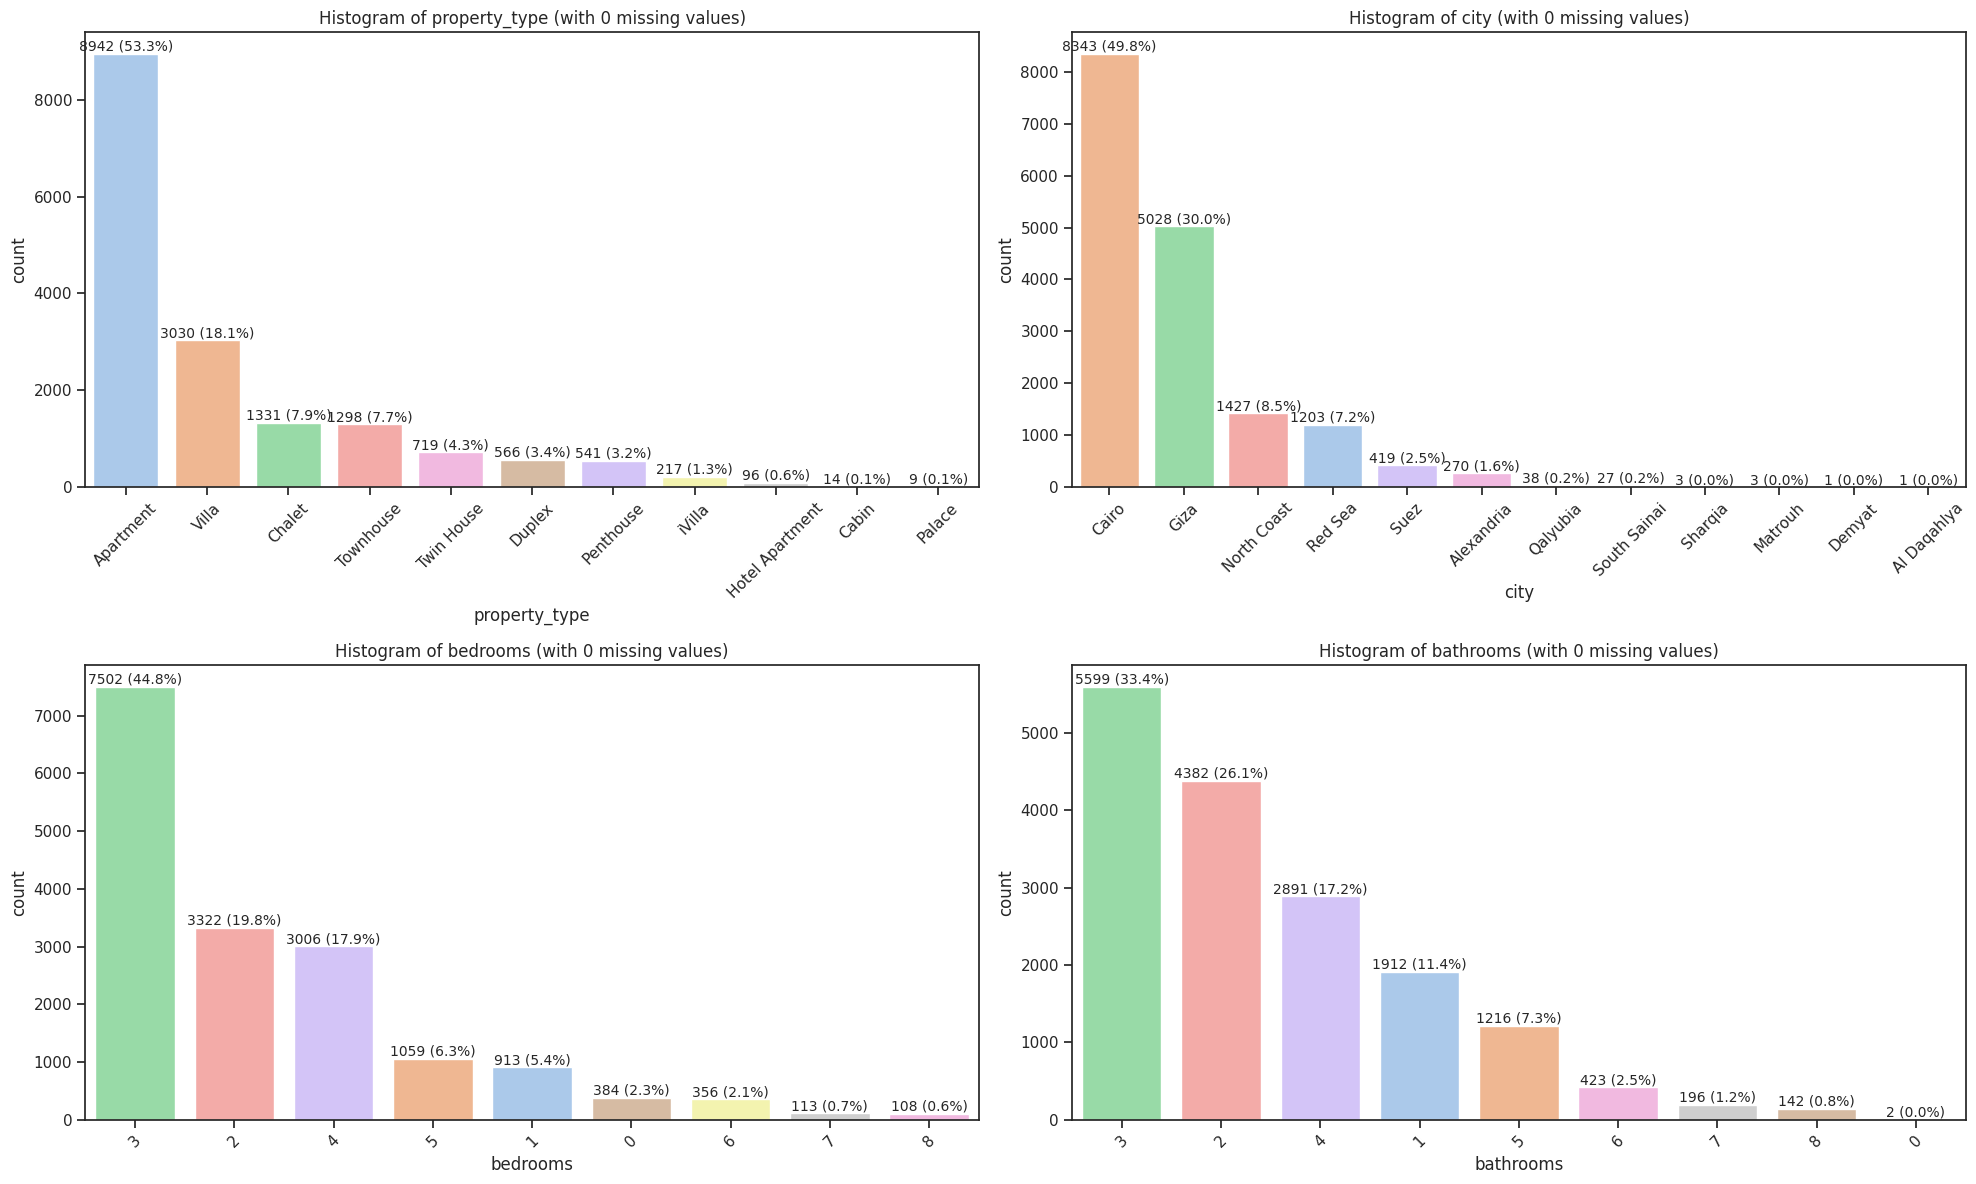

In [177]:
cat_features = ['property_type', 'city', 'bedrooms', 'bathrooms']

n_features = len(cat_features)
n_cols = 2
n_rows = (n_features + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 6 * n_rows))
axes = axes.flatten()

total_rows = len(X_train)

for i, col in enumerate(cat_features):
    if col in X_train.columns:
        missing_count = X_train[col].isna().sum()
        # Prepare data: fill NA with 'MISSING' and sort by count
        data_plot = X_train[col].astype(str).replace(['nan', '<NA>', 'None'], 'MISSING')
        order = data_plot.value_counts().index

        ax = sns.countplot(x=data_plot, ax=axes[i], palette='pastel', hue=data_plot, legend=False, order=order)

        # Add counts and proportions above bars
        for p in ax.patches:
            height = p.get_height()
            percentage = (height / total_rows) * 100
            ax.annotate(f'{int(height)} ({percentage:.1f}%)', (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='bottom', fontsize=10)

        axes[i].set_title(f'Histogram of {col} (with {missing_count} missing values)')
        axes[i].tick_params(axis='x', rotation=45)

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

The distribution of classes for ```property_type``` and ```city``` is very unbalanced, let's see if we can merge some classes.

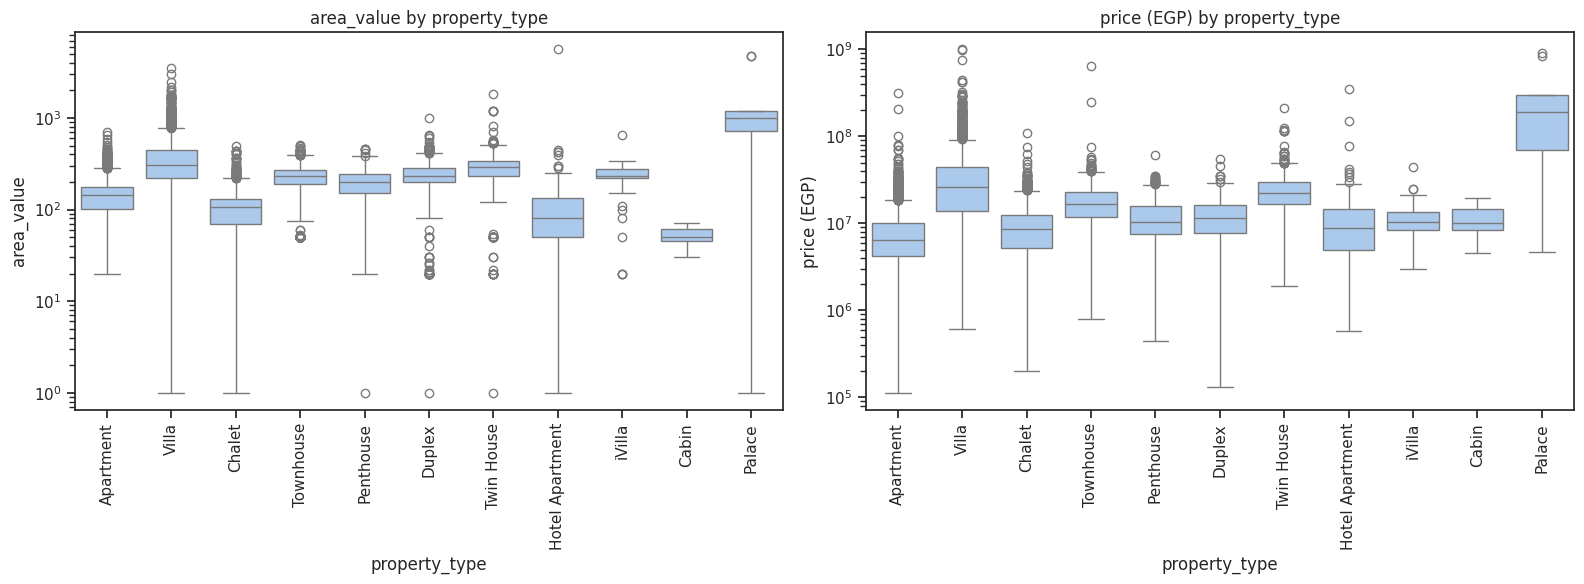

In [178]:
fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (16, 6))

sns.boxplot(data = X_train, x = 'property_type', y = 'area_value', ax = axes[0])
axes[0].set_title(f'{'area_value'} by property_type')
axes[0].set_yscale('log')
axes[0].tick_params(axis = 'x', rotation = 90)

plot_property_type_price = pd.concat([X_train['property_type'], y_train], axis = 1)

sns.boxplot(data = plot_property_type_price, x = 'property_type', y = 'price (EGP)', ax = axes[1])
axes[1].set_title(f'{'price (EGP)'} by property_type')
axes[1].set_yscale('log')
axes[1].tick_params(axis = 'x', rotation = 90)

plt.tight_layout()
plt.show()

So, we should be able to merge ```Villa``` and ```iVilla```, ```Apartment``` and ```Hotel Apartment```, ```Twin House``` and ```Townhouse```.

In [179]:
X_train['property_type'].replace(to_replace = {'iVilla' : 'Villa', 'Hotel Apartment' : 'Apartment', 'Twin House' : 'Townhouse'}, inplace = True)

/tmp/ipykernel_3842/1785786877.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_train['property_type'].replace(to_replace = {'iVilla' : 'Villa', 'Hotel Apartment' : 'Apartment', 'Twin House' : 'Townhouse'}, inplace = True)


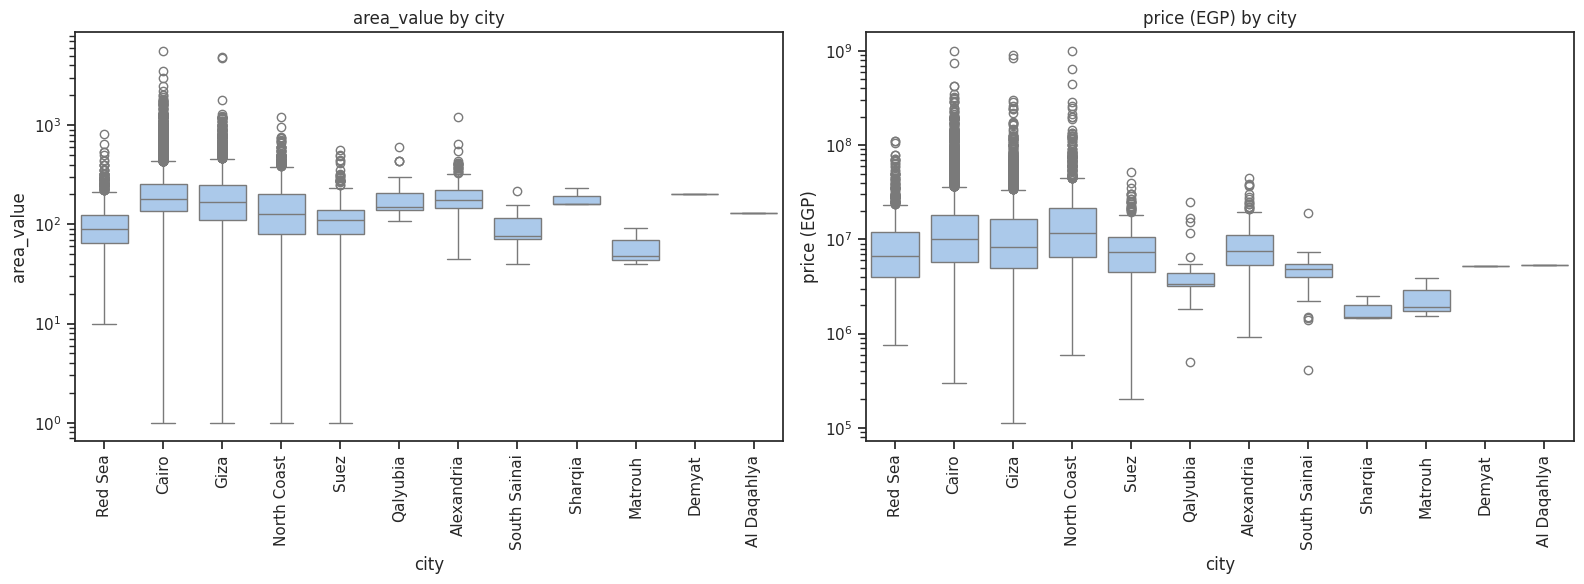

In [180]:
fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (16, 6))

sns.boxplot(data = X_train, x = 'city', y = 'area_value', ax = axes[0])
axes[0].set_title(f'{'area_value'} by city')
axes[0].set_yscale('log')
axes[0].tick_params(axis = 'x', rotation = 90)

plot_city_price = pd.concat([X_train['city'], y_train], axis = 1)

sns.boxplot(data = plot_city_price, x = 'city', y = 'price (EGP)', ax = axes[1])
axes[1].set_title(f'{'price (EGP)'} by city')
axes[1].set_yscale('log')
axes[1].tick_params(axis = 'x', rotation = 90)

plt.tight_layout()
plt.show()

Let's also merge ```Qalyubia```, ```South Sainai```, ```Matrouh```, ```Sharqia```, ```Demyat``` and ```Al Daqahlya``` into one category ```Other cities```.

In [181]:
X_train['city'].replace(to_replace = ['Qalyubia', 'South Sainai', 'Matrouh', 'Sharqia', 'Demyat', 'Al Daqahlya'], value = 'Other Cities', inplace = True)

/tmp/ipykernel_3842/2273339966.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_train['city'].replace(to_replace = ['Qalyubia', 'South Sainai', 'Matrouh', 'Sharqia', 'Demyat', 'Al Daqahlya'], value = 'Other Cities', inplace = True)


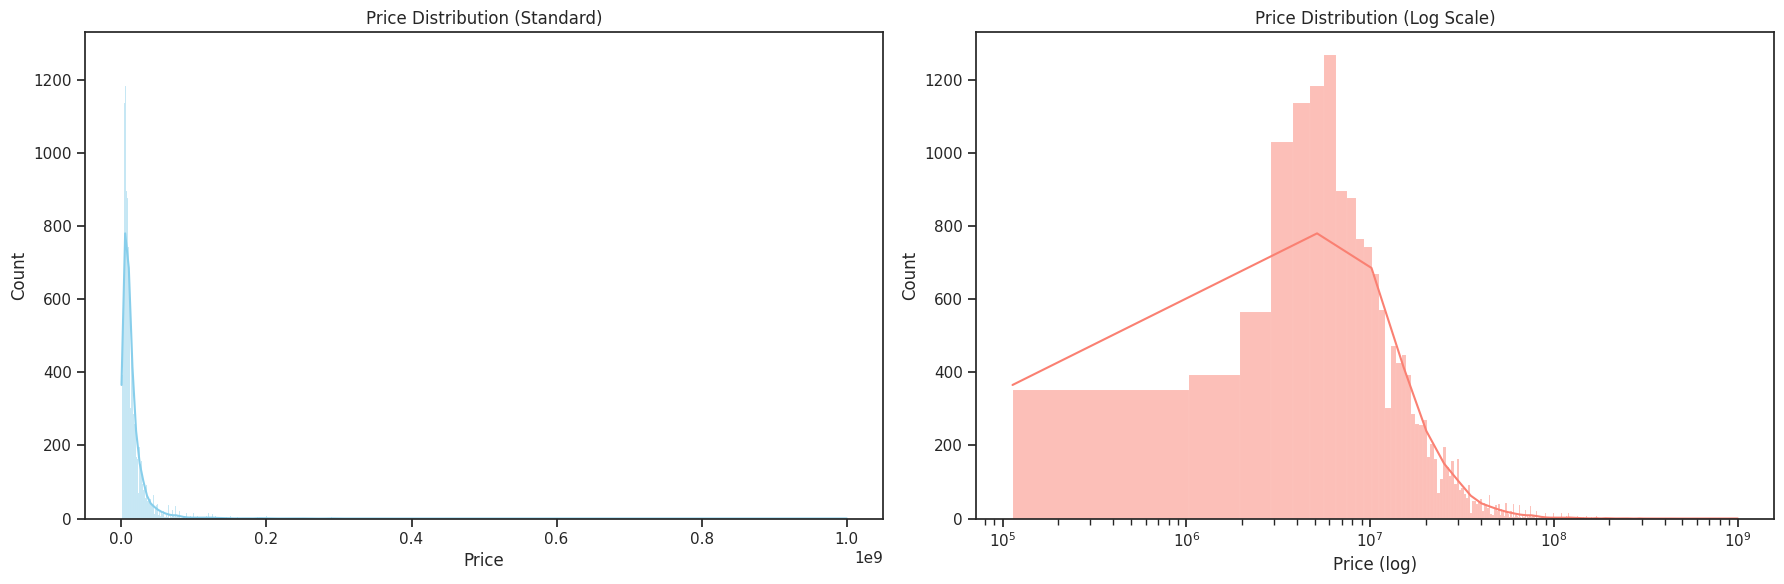

In [182]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Standard Distribution
sns.histplot(y_train, kde=True, ax=ax1, color='skyblue')
ax1.set_title('Price Distribution (Standard)')
ax1.set_xlabel('Price')

# Log-transformed Distribution
sns.histplot(y_train, kde=True, ax=ax2, color='salmon')
ax2.set_xscale('log')
ax2.set_title('Price Distribution (Log Scale)')
ax2.set_xlabel('Price (log)')

plt.tight_layout()
plt.show()

We might want to apply a log function to ```Price (EGP)``` to help the model to predict the price.

In [183]:
y_train = np.log1p(y_train)

# Creating the Pipeline

In [ ]:

class PropertyPreprocessor(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    # Custome preprocessing thanks to insights found during the EDA :
    # cleaning of 'bathrooms' and 'bedrooms', merge some property types, merge some cities
    def transform(self, X):
        X_copy = X.copy()

        X_copy['bedrooms'] = X_copy['bedrooms'].replace(['7+', 'studio'], ['8', '0'])
        X_copy['bathrooms'] = X_copy['bathrooms'].replace(['7+', 'none'], ['8', '0'])

        prop_map = {'iVilla': 'Villa', 'Hotel Apartment': 'Apartment', 'Twin House': 'Townhouse'}
        X_copy['property_type'] = X_copy['property_type'].replace(prop_map)

        others = ['Qalyubia', 'South Sainai', 'Matrouh', 'Sharqia', 'Demyat', 'Al Daqahlya']
        X_copy['city'] = X_copy['city'].replace(others, 'Other Cities')

        return X_copy

# OHE of categorical variables
preprocessor = ColumnTransformer([
    ('cat_encoding', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
     ['property_type', 'city', 'bedrooms', 'bathrooms'])
], remainder='passthrough')

# Concatenate the full pipeline
model_pipeline = Pipeline([
    ('custom_clean', PropertyPreprocessor()),
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=seed))
])

full_pipeline = TransformedTargetRegressor(
    regressor=model_pipeline,
    func=np.log1p,
    inverse_func=np.expm1
)

# Save the pipeline
joblib.dump(full_pipeline, 'price_prediction_model.joblib')

['price_prediciton_model.joblib']